# Daisyworld: параметрический отклик на светимость

Для каждого сочетания параметров повторяется полный сценарий ramp на 1000 шагах.

## Расчёт траекторий

In [1]:
using DrWatson
@quickactivate "DaisyworldLab"
include(srcdir("experiment_tools.jl"))

summary_rows = NamedTuple[]
comparison = Figure(size=(1200, 900))
for (run, base_parameters) in enumerate(parameter_sets())
    parameters = copy(base_parameters)
    parameters[:scenario] = :ramp
    model = create_world(; parameters...)
    trajectory = history_frame(model, 1000)
    save_history(trajectory, "daisyworld-luminosity__param";
                 filename="trajectory-run-$(run).csv")
    occupied = trajectory.total .> 0
    push!(summary_rows, (
        run=run, max_age=parameters[:max_age], init_white=parameters[:init_white],
        final_total=last(trajectory.total), max_temperature=maximum(trajectory.temperature),
        min_temperature=minimum(trajectory.temperature),
        living_steps=count(occupied), mean_regulation_error=mean(trajectory.regulation_error),
    ))
    ax = Axis(comparison[(run - 1) ÷ 2 + 1, (run - 1) % 2 + 1],
              title="Возраст $(parameters[:max_age]), белые $(parameters[:init_white])",
              xlabel="Шаг", ylabel="Температура, °C")
    lines!(ax, trajectory.time, trajectory.temperature; color=:firebrick)
    lines!(ax, trajectory.time, 22.5 .+ 10 .* (trajectory.luminosity .- 1);
           color=:royalblue, linestyle=:dash)
end

## Сравнение устойчивости

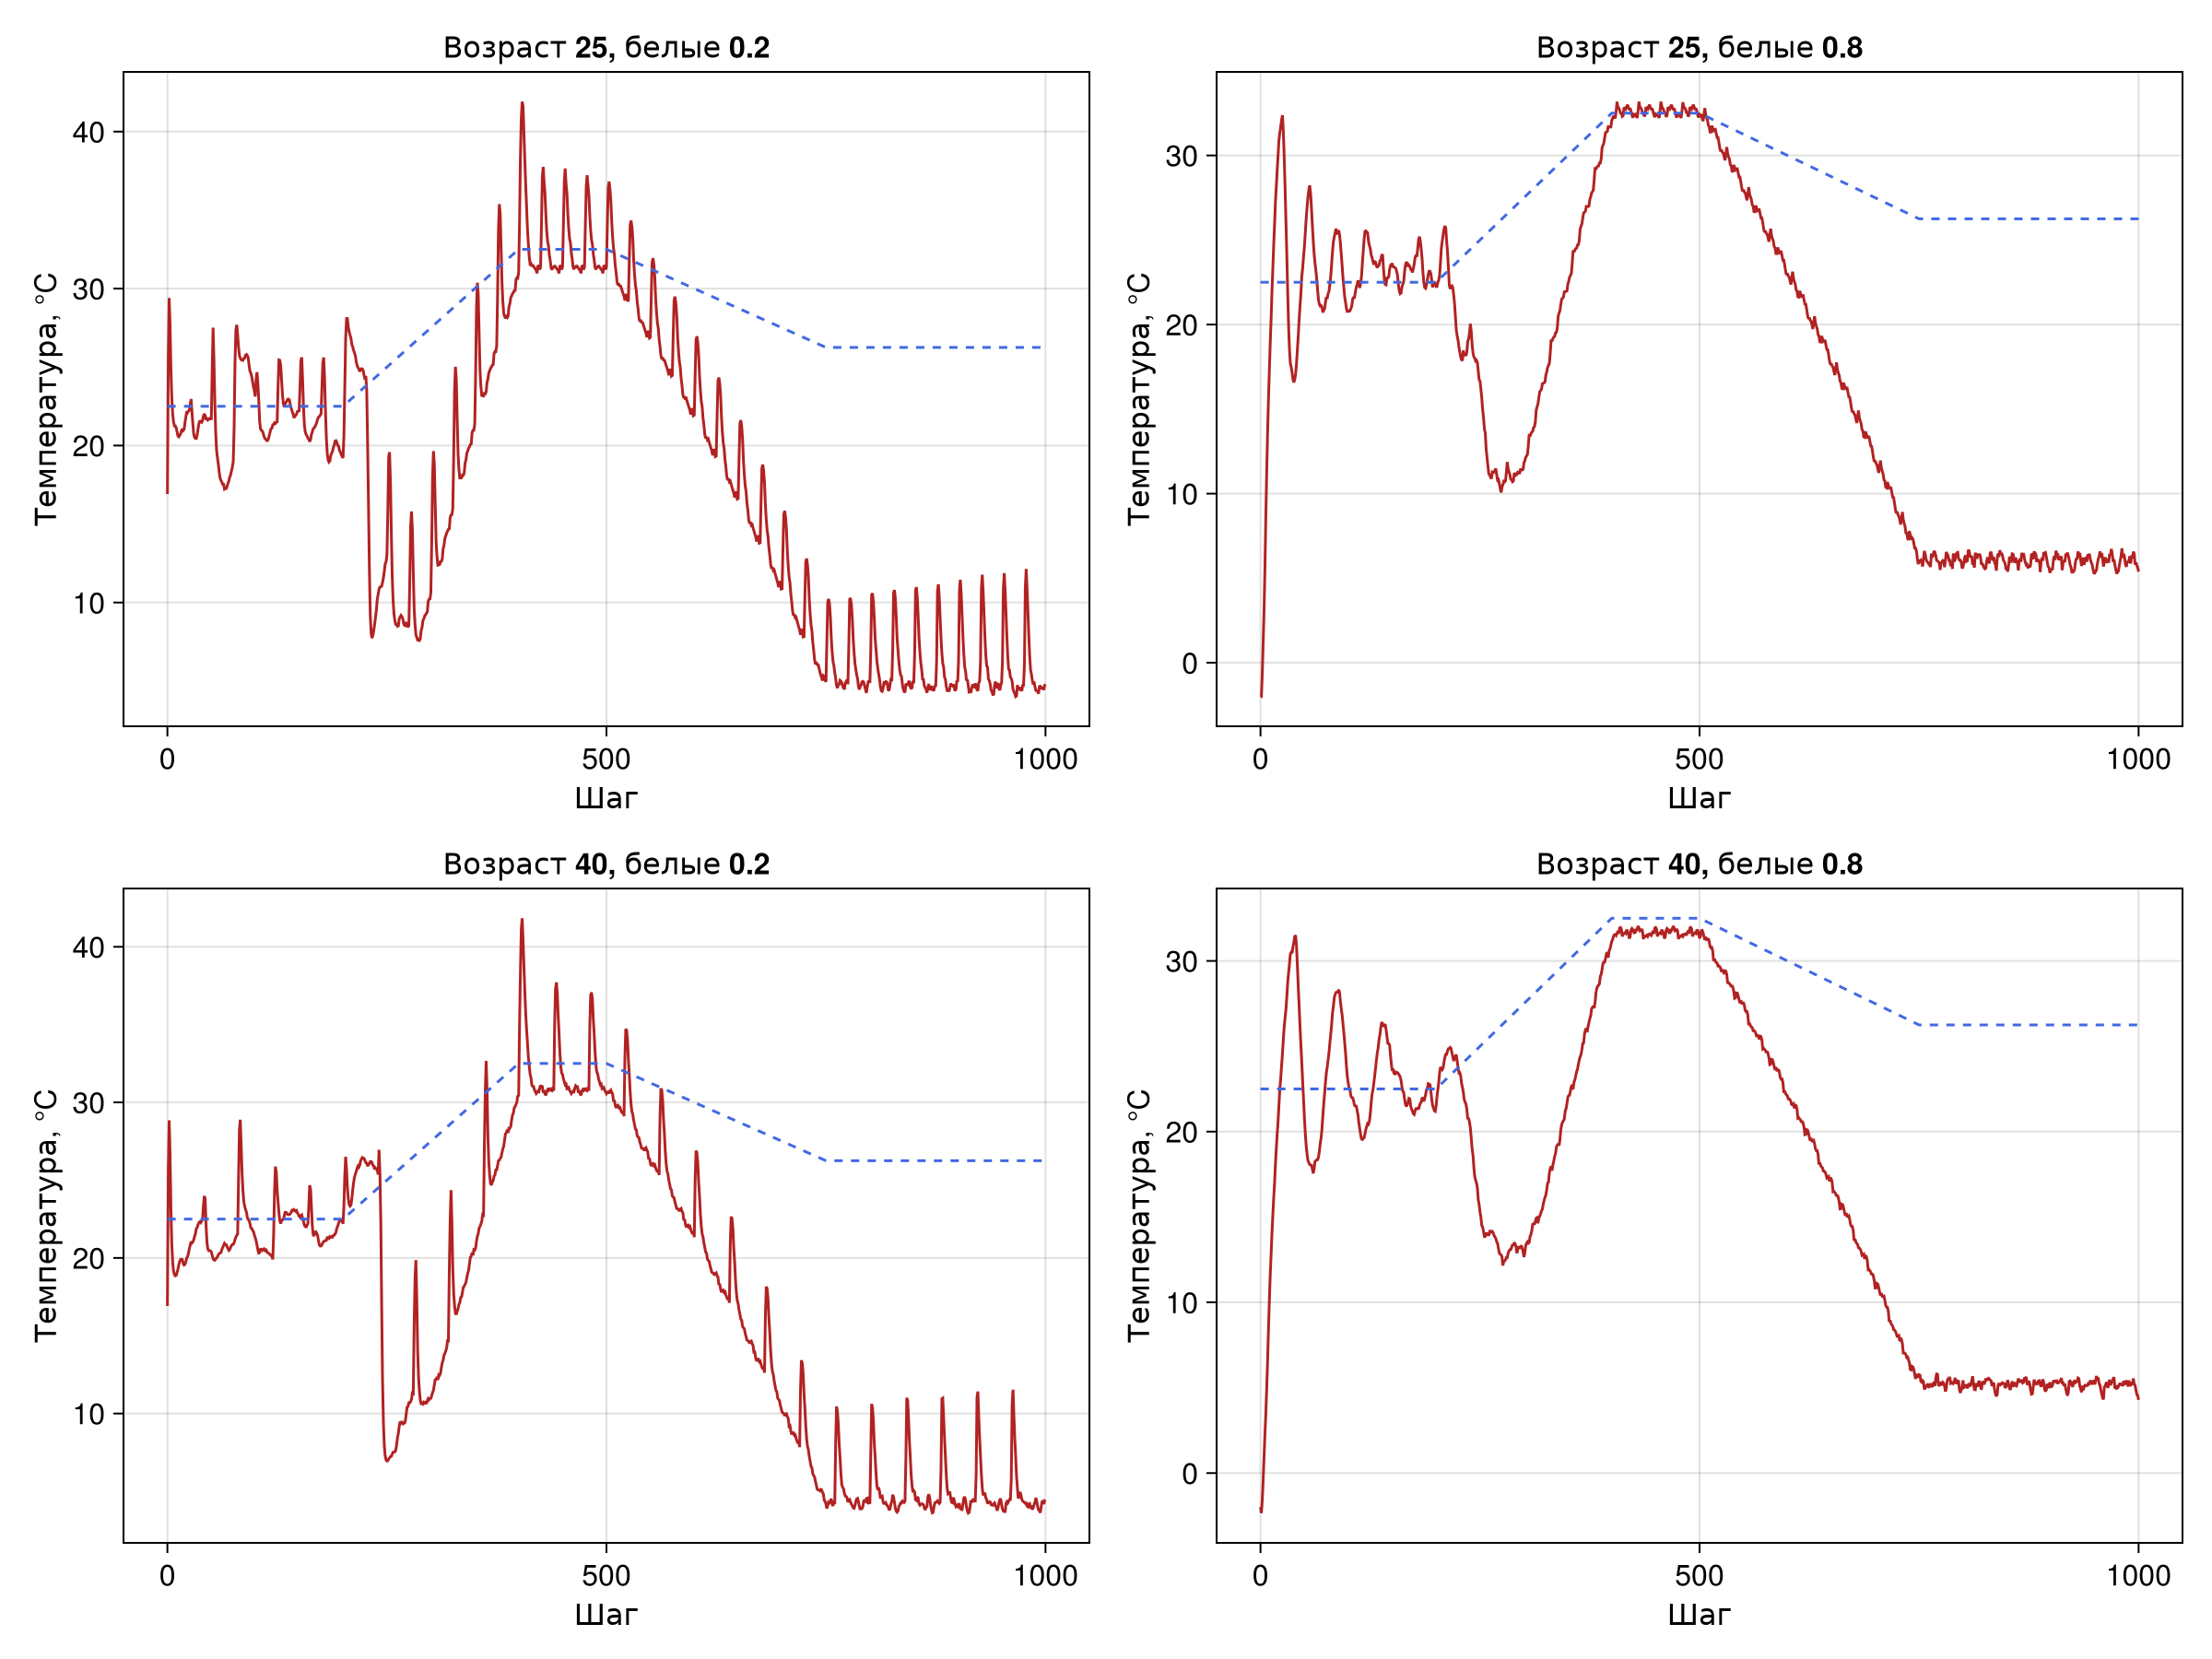

Row,run,max_age,init_white,final_total,max_temperature,min_temperature,living_steps,mean_regulation_error
,Int64,Int64,Float64,Int64,Float64,Float64,Int64,Float64
1,1,25,0.2,894,41.9092,4.01109,1001,8.8315
2,2,25,0.8,897,33.181,-1.99719,1001,8.58064
3,3,40,0.2,893,41.8342,3.60095,1001,8.76476
4,4,40,0.8,899,32.039,-2.34738,1001,8.774


In [2]:
save_figure(comparison, "daisyworld-luminosity__param", "temperature-grid.png";
            report_name="parameter-temperature-comparison.png")
display(comparison)
summary = DataFrame(summary_rows)
CSV.write(scenario_data("daisyworld-luminosity__param", "summary.csv"), summary)
summary